In [0]:
%pip install tensorflow-cpu==2.12
%pip install prophet

Python interpreter will be restarted.
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.5
    Not uninstalling numpy at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-c8d4d2bd-30dc-47fe-a962-a550eaba6606
    Can't uninstall 'numpy'. No files were found to uninstall.
  Attempting uninstall: scipy
    Found existing installation: scipy 1.7.3
    Not uninstalling scipy at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-c8d4d2bd-30dc-47fe-a962-a550eaba6606
    Can't uninstall 'scipy'. No files were found to uninstall.
  Attempting uninstall: MarkupSafe
    Found existing installation: MarkupSafe 2.0.1
    Not uninstalling markupsafe at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-c8d4d2bd-30dc-47fe-a962-a550eaba6606
    Can't uninstall 'MarkupSafe'. No files were found to u

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from pyspark.sql import SparkSession
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, DateType, FloatType

spark = SparkSession.builder.appName("StockForcasting").getOrCreate()


#### Below Community Version Only - data would be saved in a different area and loaded in accordingly

In [0]:
path = "dbfs:/FileStore/shared_uploads/vgoon277@gmail.com/"
file_name = "nvidia_stock_data-4.csv"

df = spark.read.csv(path+"/"+file_name,
  header=True,
  inferSchema=True)


In [0]:
# save the data - if it already exists - overwrite it with current data
df.write.mode("overwrite").format("parquet").saveAsTable("stock_data")
df = spark.sql("SELECT DATE, OPEN_NVDA FROM stock_data")
df = df.toPandas()
df.head()

,DATE,OPEN_NVDA
0,1999-01-22,0.040119
1,1999-01-25,0.040597
2,1999-01-26,0.042029
3,1999-01-27,0.038447
4,1999-01-28,0.038209


#### ^ Above Community Version Only - data would be saved in a different area and loaded in accordingly

In [0]:
# schema = StructType([
#     StructField("ds", DateType()),
#     StructField("yhat", FloatType()),
# ])

# @pandas_udf(schema, functionType=PandasUDFType.GROUPED_MAP)
def run_model(pdf):
    pdf = pdf.rename(columns={"DATE": "ds", "OPEN_NVDA": "y"})
    model = Prophet()
    model.fit(pdf)

    future = model.make_future_dataframe(periods=7)
    target = model.predict(future)
    
    model.plot(target)

    return target

19:02:51 - cmdstanpy - INFO - Chain [1] start processing
19:02:53 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
6583,2025-03-25,98.541272,84.599478,112.434011
6584,2025-03-26,98.468240,85.331819,112.720823
6585,2025-03-27,98.615636,84.599668,112.594349
6586,2025-03-28,98.677275,85.344562,111.905334
6587,2025-03-29,98.612527,85.415179,112.283446
6588,2025-03-30,98.632496,84.664196,111.131453
6589,2025-03-31,98.826363,84.633279,112.708199
6590,2025-04-01,98.723533,85.351123,111.856595
6591,2025-04-02,98.610608,85.440660,111.685992
6592,2025-04-03,98.719353,84.258637,111.507319


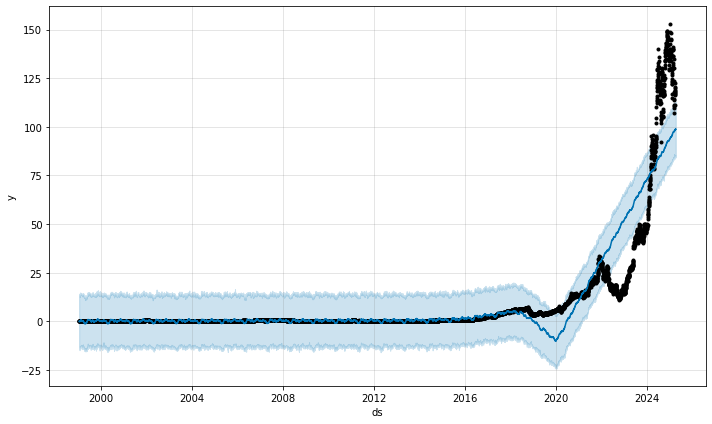

In [0]:
target_df = run_model(df)
target_df[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7)

In [0]:
target
    .write
    .format("delta")
    .mode("overwrite")          # or "append" to keep history
    .saveAsTable("stocks.forecasts")

In [0]:
# 04_forecast_prophet
# 1) Install Prophet on your cluster (one‑time):
#    %pip install prophet

# from pyspark.sql import SparkSession
# from pyspark.sql.functions import pandas_udf
# from pyspark.sql.types import StructType, StructField, StringType, TimestampType, DoubleType
# import pandas as pd
# from prophet import Prophet

# spark = SparkSession.builder.getOrCreate()

# 2) Define output schema for our forecasts
forecast_schema = StructType([
    StructField("ticker", StringType(), True),
    StructField("ds",      TimestampType(), True),
    StructField("yhat",    DoubleType(),   True),
])

# 3) Grouped‑map UDF: fit Prophet per ticker and emit next‑7‑day forecasts
@pandas_udf(forecast_schema, functionType="GROUPED_MAP")
def forecast_7d(pdf: pd.DataFrame) -> pd.DataFrame:
    # pdf has columns ["ticker","ds","close","ma7","ret1","ret7",...]
    pdf = pdf.sort_values("ds")
    # rename our target column
    df_prophet = pdf[["ds","close"]].rename(columns={"close":"y"})
    # initialize & fit
    m = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False
    )
    m.fit(df_prophet)
    # make 7‑day future frame
    future = m.make_future_dataframe(periods=7, include_history=False)
    fc     = m.predict(future)
    # return only ticker, ds, yhat
    return pd.DataFrame({
        "ticker": pdf["ticker"].iat[0],
        "ds":      fc["ds"],
        "yhat":    fc["yhat"]
    })

# 4) Load your preprocessed features (we only need ds & close here)
df_input = (
    spark.table("stocks.silver_features")
      .select("ticker","ds","close")
      .repartition("ticker")    # ensure each ticker is processed independently
)

# 5) Apply the UDF and write forecasts
forecasts = df_input.groupBy("ticker").apply(forecast_7d)

(
    forecasts
      .write
      .format("delta")
      .mode("overwrite")          # or "append" to keep history
      .saveAsTable("stocks.forecasts_7d")
)

print("✅ 7‑day forecasts written to stocks")

In [0]:
# # 1) Install dependencies (run once per cluster)
# # %pip install requests

# from pyspark.sql import SparkSession
# import requests
# import pandas as pd
# from datetime import datetime

# # 2) Initialize Spark
# spark = SparkSession.builder.getOrCreate()

# # 3) Parameters: list of tickers & API key stored in Databricks Secret Scope "market"
# symbols  = ["INTC", "NVDA", "AMD"]
# api_key  = dbutils.secrets.get("market", "alpha_key")

# # 4) Fetch today’s daily-adjusted data for each ticker
# today_str = datetime.today().strftime("%Y-%m-%d")
# records   = []

# for symbol in symbols:
#     url = "https://www.alphavantage.co/query"
#     params = {
#         "function":   "TIME_SERIES_DAILY_ADJUSTED",
#         "symbol":     symbol,
#         "apikey":     api_key,
#         "outputsize": "compact"
#     }
#     resp = requests.get(url, params=params)
#     ts   = resp.json().get("Time Series (Daily)", {})

#     if today_str in ts:
#         vals = ts[today_str]
#         records.append({
#             "ticker": symbol,
#             "ds":      pd.to_datetime(today_str),
#             "open":    float(vals["1. open"]),
#             "high":    float(vals["2. high"]),
#             "low":     float(vals["3. low"]),
#             "close":   float(vals["4. close"]),
#             "volume":  int(vals["6. volume"])
#         })
#     else:
#         print(f"No data for {symbol} on {today_str}")

# # 5) Convert to Spark DataFrame & append to your Delta table
# if records:
#     df_pd    = pd.DataFrame(records)
#     df_spark = spark.createDataFrame(df_pd)
#     (
#         df_spark
#           .write
#           .format("delta")
#           .mode("append")  
#           .saveAsTable("stocks.bronze_prices")
#     )
#     tickers_done = ", ".join(r["ticker"] for r in records)
#     print(f"Ingested data for {tickers_done} on {today_str}")
# else:
#     print("No records ingested today.")


In [0]:
# 03_preprocess
# Dependencies: none beyond default Spark libraries

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder.getOrCreate()

# 1) Read your bronze table
df = spark.table("stocks.bronze_prices")  
# columns: ticker (string), ds (timestamp), open, high, low, close, volume

# 2) Define a window to compute rolling features
w7 = Window.partitionBy("ticker").orderBy("ds").rowsBetween(-6, 0)

# 3) Clean & feature‐engineer
df_features = (
    df
      # ensure ordering & drop any junk
      .filter(F.col("close").isNotNull())
      .withColumn("ma7", F.avg("close").over(w7))           # 7‑day moving avg
      .withColumn("ret1", (F.col("close") / F.lag("close",1).over(w7)) - 1)
      .withColumn("ret7", (F.col("close") / F.lag("close",7).over(w7)) - 1)
      # drop rows where our rolling windows haven't filled yet
      .na.drop(subset=["ma7","ret1","ret7"])
)

# 4) Persist to a “silver” Delta table
(
    df_features
      .write
      .format("delta")
      .mode("overwrite")               # or "append" if you prefer incremental
      .saveAsTable("stocks.silver_features")
)

print("✅ Preprocessing complete: features written to stocks.silver_features")


In [0]:
# # 04_forecast_prophet
# # 1) Install Prophet on your cluster (one‑time):
# #    %pip install prophet

# from pyspark.sql import SparkSession
# from pyspark.sql.functions import pandas_udf
# from pyspark.sql.types import StructType, StructField, StringType, TimestampType, DoubleType
# import pandas as pd
# from prophet import Prophet

# spark = SparkSession.builder.getOrCreate()

# # 2) Define output schema for our forecasts
# forecast_schema = StructType([
#     StructField("ticker", StringType(), True),
#     StructField("ds",      TimestampType(), True),
#     StructField("yhat",    DoubleType(),   True),
# ])

# # 3) Grouped‑map UDF: fit Prophet per ticker and emit next‑7‑day forecasts
# @pandas_udf(forecast_schema, functionType="GROUPED_MAP")
# def forecast_7d(pdf: pd.DataFrame) -> pd.DataFrame:
#     # pdf has columns ["ticker","ds","close","ma7","ret1","ret7",...]
#     pdf = pdf.sort_values("ds")
#     # rename our target column
#     df_prophet = pdf[["ds","close"]].rename(columns={"close":"y"})
#     # initialize & fit
#     m = Prophet(
#         weekly_seasonality=True,
#         yearly_seasonality=True,
#         daily_seasonality=False
#     )
#     m.fit(df_prophet)
#     # make 7‑day future frame
#     future = m.make_future_dataframe(periods=7, include_history=False)
#     fc     = m.predict(future)
#     # return only ticker, ds, yhat
#     return pd.DataFrame({
#         "ticker": pdf["ticker"].iat[0],
#         "ds":      fc["ds"],
#         "yhat":    fc["yhat"]
#     })

# # 4) Load your preprocessed features (we only need ds & close here)
# df_input = (
#     spark.table("stocks.silver_features")
#       .select("ticker","ds","close")
#       .repartition("ticker")    # ensure each ticker is processed independently
# )

# # 5) Apply the UDF and write forecasts
# forecasts = df_input.groupBy("ticker").apply(forecast_7d)

# (
#     forecasts
#       .write
#       .format("delta")
#       .mode("overwrite")          # or "append" to keep history
#       .saveAsTable("stocks.forecasts_7d")
# )

# print("✅ 7‑day forecasts written to stocks

In [0]:
# 05_analysis
# 1) (One‐time) install Plotly
# %pip install plotly

from pyspark.sql import SparkSession
import pandas as pd
import plotly.express as px
from pyspark.sql.functions import col

# 2) Init Spark
spark = SparkSession.builder.getOrCreate()

# 3) Load raw prices and forecasts
raw_df = (
    spark
      .table("stocks.bronze_prices")
      .select("ticker", "ds", col("close").alias("actual"))
)
fc_df = (
    spark
      .table("stocks.forecasts_7d")
      .select("ticker", "ds", col("yhat").alias("predicted"))
)

# 4) Join on ticker + date
cmp_df = raw_df.join(fc_df, on=["ticker","ds"], how="inner")

# 5) Show the joined table for quick inspection
display(cmp_df)

# 6) Convert to Pandas for Plotly
cmp_pd = cmp_df.toPandas()

# 7) Plot actual vs. forecast for each ticker
for symbol in cmp_pd["ticker"].unique():
    sub = cmp_pd[cmp_pd["ticker"] == symbol]
    fig = px.line(
        sub,
        x="ds",
        y=["actual","predicted"],
        labels={"value":"Price","ds":"Date"},
        title=f"{symbol}: Actual vs. 7‑Day Forecast"
    )
    fig.update_layout(legend_title="Series")
    fig.show()

# 8) Compute forecast error and plot its distribution
cmp_pd["error"] = cmp_pd["actual"] - cmp_pd["predicted"]
fig2 = px.histogram(
    cmp_pd,
    x="error",
    nbins=40,
    labels={"error":"Forecast Error"},
    title="Distribution of Forecast Errors (Actual − Predicted)"
)
fig2.show()
